In [1]:
import os, sys
import numpy as np
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(os.path.join(module_path, "KAN_variants"))
from ChebyKANLayer import ChebyKAN

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(os.path.join(module_path, "code"))
from myKANODE import KANODE

In [2]:
def pred_prey_deriv(X, t, alpha, beta, delta, gamma):
    x=X[0]
    y=X[1]
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dXdt=[dxdt, dydt]
    return dXdt

# alpha, beta, delta, gamma
params = [1.5, 1, 2, 1]
X0 = [0.1, 1.5]

In [3]:
stepSizes = np.linspace(0.005, 0.1, 4)

 21%|██        | 1053/5000 [3:13:02<12:03:34, 11.00s/it]


stepSize: 0.005


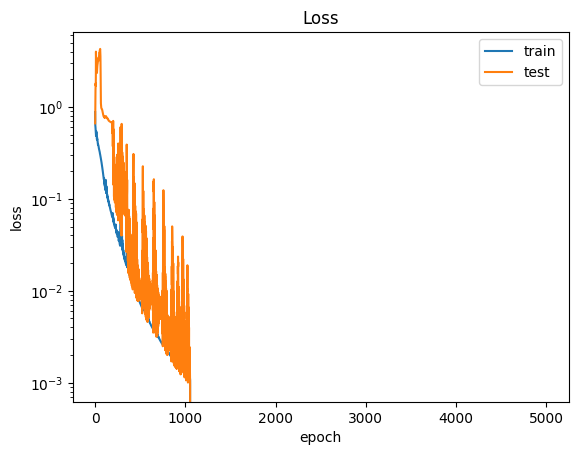

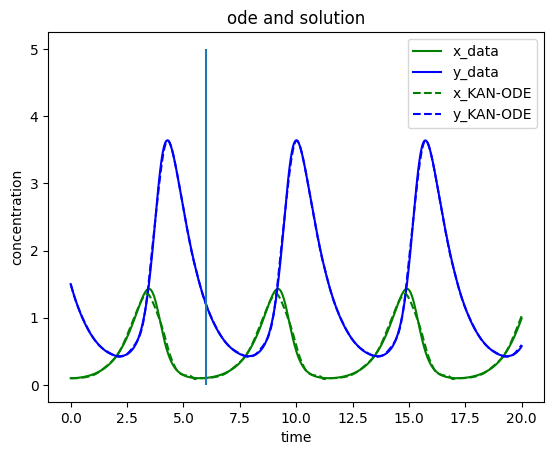

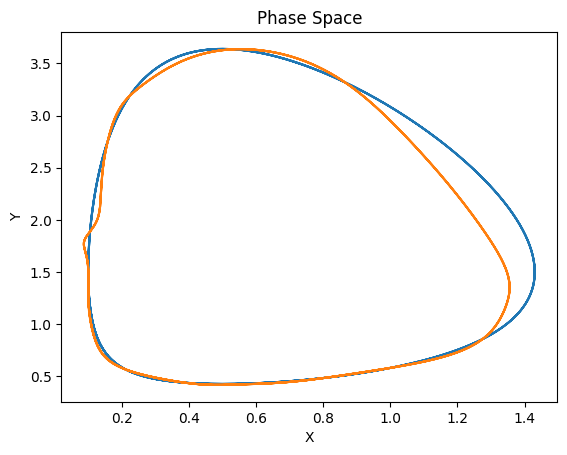

 23%|██▎       | 1126/5000 [26:48<1:32:13,  1.43s/it]


stepSize: 0.03666666666666667


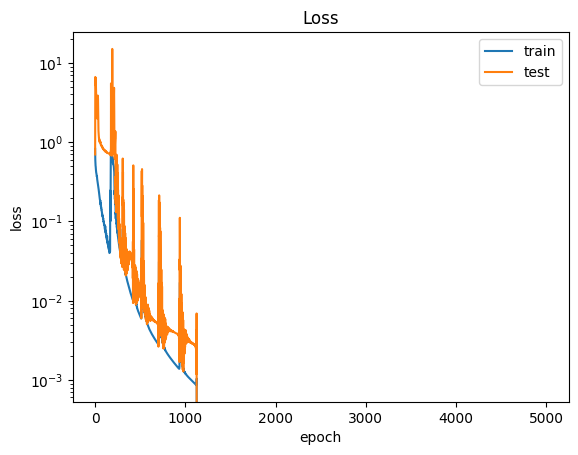

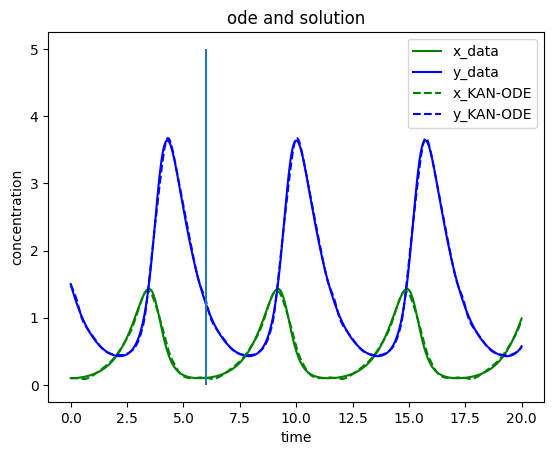

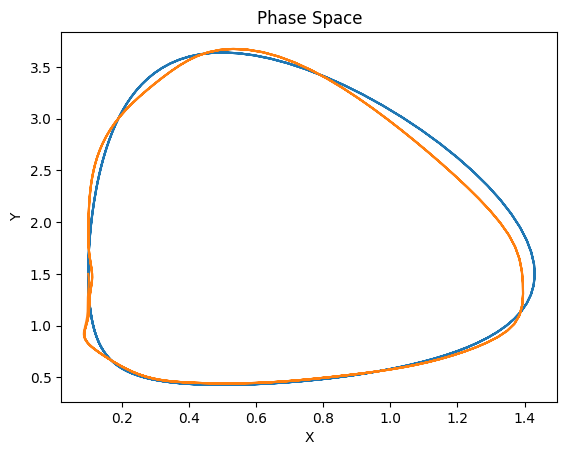

 89%|████████▊ | 4434/5000 [56:11<07:10,  1.32it/s] 


stepSize: 0.06833333333333334


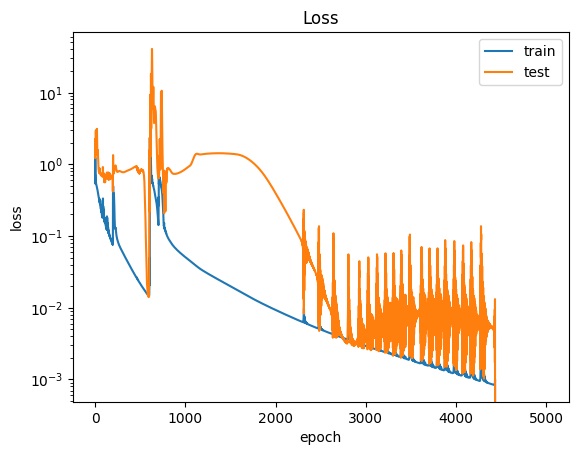

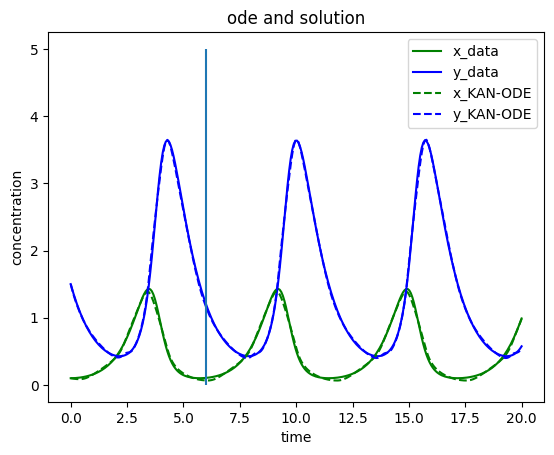

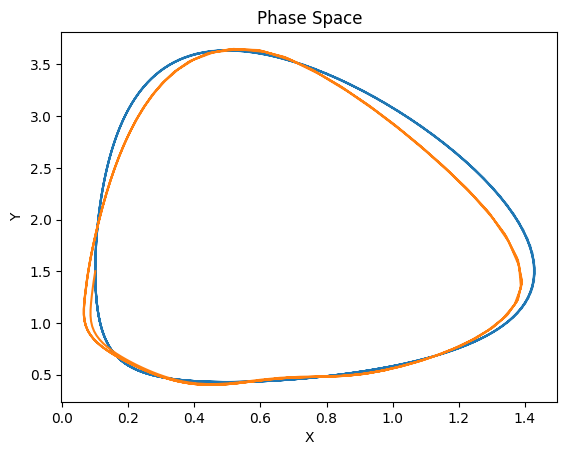

 89%|████████▊ | 4428/5000 [38:38<04:59,  1.91it/s]


stepSize: 0.1


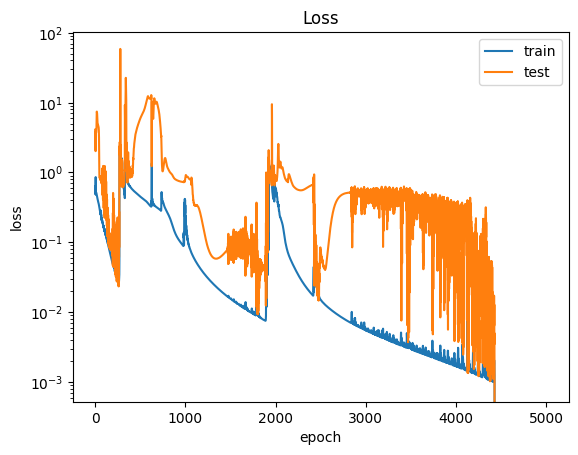

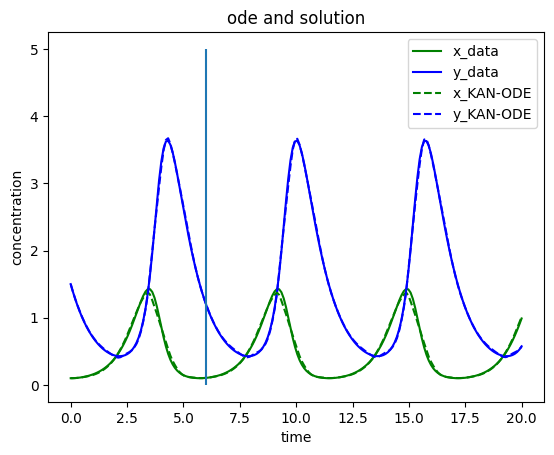

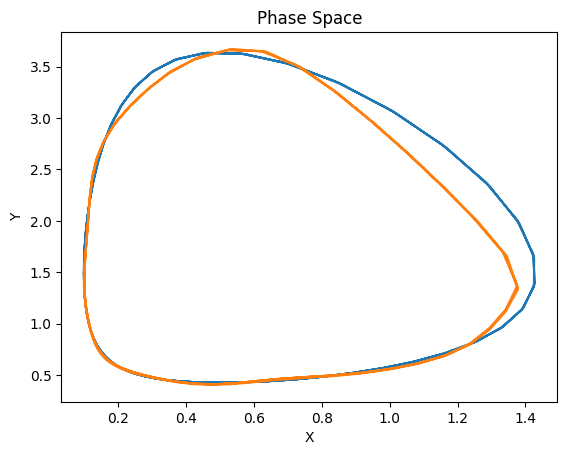

In [4]:
for stepSize in stepSizes:
    saveDirectory = os.path.join(module_path, "savedModels", "stepSizeSweep", f"stepSize-{stepSize}")
    if not os.path.isdir(saveDirectory):
        os.makedirs(saveDirectory)
    model = ChebyKAN([2, 7, 7, 2], 4)
    kanODE = KANODE(model, pred_prey_deriv, X0, params, 20, 6, stepSize)
    kanODE.train(-1, maxEpochs=5000, solverMethod="rk4", saveDirectory=saveDirectory, saveCooldown=100, evalThreshold=10**-3)
    print(f"stepSize: {stepSize}")
    _, solution = kanODE.test()
    kanODE.plotLoss("Loss")
    kanODE.plotODE("ode and solution", solution[:, 0, :])
    kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])

 20%|█▉        | 983/5000 [5:24:32<22:06:15, 19.81s/it]


stepSize: 0.003


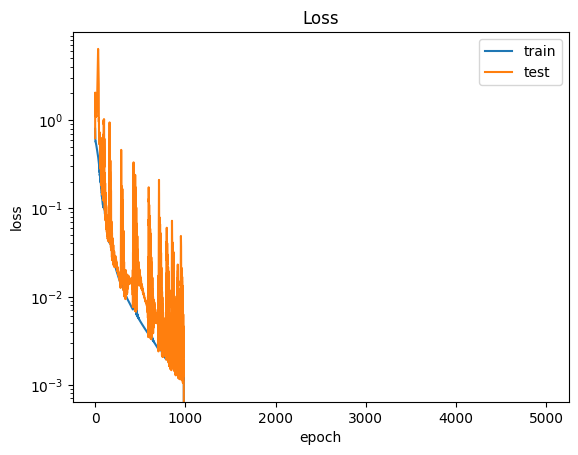

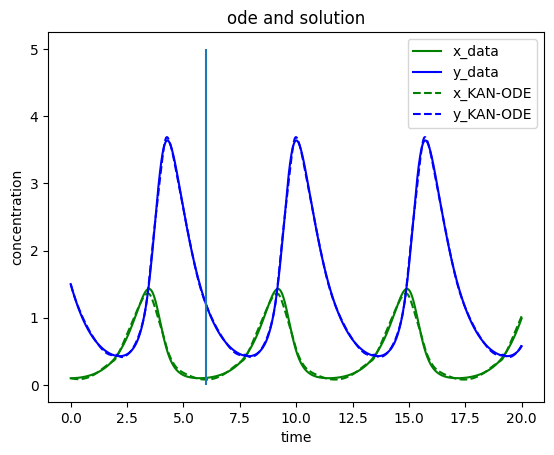

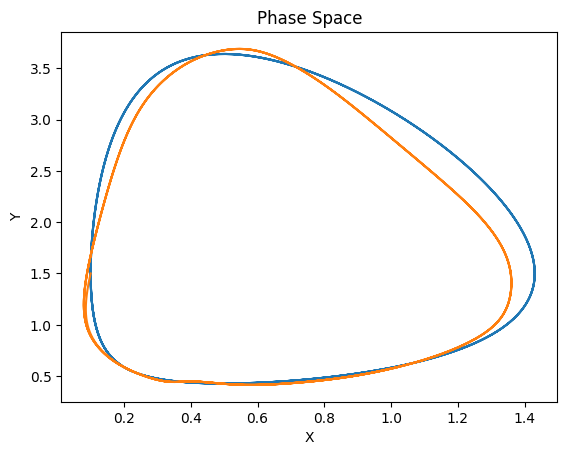

  0%|          | 1/5000 [00:29<41:01:13, 29.54s/it]

: 

In [5]:
stepSizes = np.linspace(0.003, 0.0008, 3)
for stepSize in stepSizes:
    saveDirectory = os.path.join(module_path, "savedModels", "stepSizeSweep", f"stepSize-{stepSize}")
    if not os.path.isdir(saveDirectory):
        os.makedirs(saveDirectory)
    model = ChebyKAN([2, 7, 7, 2], 4)
    kanODE = KANODE(model, pred_prey_deriv, X0, params, 20, 6, stepSize)
    kanODE.train(-1, maxEpochs=5000, solverMethod="rk4", saveDirectory=saveDirectory, saveCooldown=100, evalThreshold=10**-3)
    print(f"stepSize: {stepSize}")
    _, solution = kanODE.test()
    kanODE.plotLoss("Loss")
    kanODE.plotODE("ode and solution", solution[:, 0, :])
    kanODE.plotPhaseSpace("Phase Space", solution[:, 0, :])